# ASPR
*Administration for Strategic Planning & Preparedness*

## Test to Treat
While vaccines remain the most effective way to prevent COVID-19 infection, there are also treatments available for people who are infected with the disease. These treatments may help individuals avoid severe illness, hospitalization, and death.

In [2]:
import pandas as pd
import matplotlib
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
aspr = pd.read_csv("ASPR_Treatments_Locator_20250104.csv", low_memory=False)

In [4]:
# Display the size and data types
aspr_shape = aspr.shape
print(f' The dataframe has {aspr_shape}[0] rows and {aspr_shape}[1] columns')

print(aspr.info())

 The dataframe has (881488, 34)[0] rows and (881488, 34)[1] columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881488 entries, 0 to 881487
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Provider Name                   881488 non-null  object 
 1   Address 1                       881488 non-null  object 
 2   Address 2                       111289 non-null  object 
 3   City                            881488 non-null  object 
 4   State                           881488 non-null  object 
 5   Zip                             881488 non-null  object 
 6   Public Phone                    245389 non-null  object 
 7   Latitude                        881488 non-null  float64
 8   Longitude                       881488 non-null  float64
 9   Geopoint                        881488 non-null  object 
 10  Last Report Date                881485 non-null  object 
 11  Is PAP Sit

In [5]:
# Check the first few lines

aspr.head()

,Provider Name,Address 1,Address 2,City,State,Zip,Public Phone,Latitude,Longitude,Geopoint,...,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Grantee Code,Is Flu,Is COVID-19
0,CVS PHARMACY #05246,110 HWY 98,NaN,PORT SAINT JOE,FL,32456,NaN,30.016430,-85.430510,POINT (-85.43051 30.01643),...,False,False,False,False,False,False,False,CV1,False,True
1,PUBLIX PHARMACY #0567,2517 SOUTH FEDERAL HIGHWAY,NaN,FT PIERCE,FL,34982,NaN,27.319630,-80.316317,POINT (-80.316317 27.31963),...,False,False,False,False,False,False,False,PX1,False,True
2,WALGREENS #4379,4320 26TH ST W,NaN,BRADENTON,FL,34205-3563,NaN,27.462954,-82.588373,POINT (-82.588373 27.462954),...,False,False,False,False,False,False,False,WG1,False,True
3,PUBLIX PHARMACY #0894,6820 OKEECHOBEE BLVD,NaN,WEST PALM BEACH,FL,33411,NaN,26.705894,-80.150789,POINT (-80.150789 26.705894),...,False,False,False,False,False,False,False,PX1,False,True
4,PUBLIX PHARMACY #0019,731 DUVAL STATION RD SUITE 4,NaN,JACKSONVILLE,FL,32218,NaN,30.485316,-81.604614,POINT (-81.604614 30.485316),...,False,False,False,False,False,False,False,PX1,False,True


In [6]:
# Check the last few lines

aspr.tail()

,Provider Name,Address 1,Address 2,City,State,Zip,Public Phone,Latitude,Longitude,Geopoint,...,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Grantee Code,Is Flu,Is COVID-19
881483,PILL PLUS PHARMACY,4215 CONNECTICUT AVE NW # ST1,NaN,WASHINGTON,DC,20008-1159,NaN,38.943706,-77.062826,POINT (-77.062826 38.943706),...,False,False,False,False,False,False,False,NaN,False,True
881484,HEALING TOUCH PHARMACY 03,3415 23RD ST SE,NaN,WASHINGTON,DC,20020-1921,NaN,38.847577,-76.971292,POINT (-76.971292 38.847577),...,False,False,False,False,False,False,False,NaN,False,True
881485,AVITA PHARMACY 1071,600 PENNSYLVANIA AVE SE,LOWER LEVEL A,WASHINGTON,DC,20003-4316,NaN,38.885207,-76.998125,POINT (-76.998125 38.885207),...,False,False,False,False,False,False,False,NaN,False,True
881486,AHF PHARMACY,650 PENNSYLVANIA AVE SE,STE 380,WASHINGTON,DC,25601,NaN,38.885410,-76.997035,POINT (-76.997035 38.88541),...,False,False,False,False,False,False,False,NaN,False,True
881487,Canyonlands HC - Duncan Pharmacy,103 Fairgrounds Rd,NaN,Duncan,AZ,85534,928-645-9675,32.726224,-109.098057,POINT (-109.098057 32.726224),...,False,False,False,False,False,False,False,HR2,False,True


In [7]:
# Checking for nulls
print(aspr.isnull().any().any())
aspr.isnull().sum()

True


Provider Name                          0
Address 1                              0
Address 2                         770199
City                                   0
State                                  0
Zip                                    0
Public Phone                      636099
Latitude                               0
Longitude                              0
Geopoint                               0
Last Report Date                       3
Is PAP Site                            0
Prescribing Services Available    866018
Appointment URL                   874429
Home Delivery                          0
Is ICATT Site                          0
Has USG Product                        0
Has Commercial Product                 0
Has Paxlovid                           0
Has Commercial Paxlovid                0
Has USG Paxlovid                       0
Has Lagevrio                           0
Has Commercial Lagevrio                0
Has USG Lagevrio                       0
Has Veklury     

In [8]:
# Remove columns
cols_to_drop = ['Address 1', 'Address 2', 'Latitude', 'Longitude', 'Geopoint', 'Public Phone', 'Prescribing Services Available', 'Appointment URL', 'Grantee Code']

aspr = aspr.drop(columns= cols_to_drop)

aspr.head()

,Provider Name,City,State,Zip,Last Report Date,Is PAP Site,Home Delivery,Is ICATT Site,Has USG Product,Has Commercial Product,...,Has USG Lagevrio,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Is Flu,Is COVID-19
0,CVS PHARMACY #05246,PORT SAINT JOE,FL,32456,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,PUBLIX PHARMACY #0567,FT PIERCE,FL,34982,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,WALGREENS #4379,BRADENTON,FL,34205-3563,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,PUBLIX PHARMACY #0894,WEST PALM BEACH,FL,33411,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,PUBLIX PHARMACY #0019,JACKSONVILLE,FL,32218,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [9]:
# Dropping null
aspr_clean = aspr.dropna()

In [10]:
# checking null
print(aspr_clean.isnull().any().any())

False


In [11]:
#filtered_data = kick_starter[kick_starter['State'] == 'successful']

# Group by Category and State and sum the specified columns
#top_ten_cats = filtered_data.groupby(['Category', 'State'])[['Backers', 'Usd Pledged Real']].sum().reset_index()

# Sort the entire DataFrame by 'Usd Pledged Real' in descending order
#top_ten_cats = top_ten_cats.sort_values(by='Usd Pledged Real', ascending=False)

#top_ten_cats.head()

In [12]:
# changing clean back to aspr
aspr_clean = aspr

In [13]:
aspr.columns

Index(['Provider Name', 'City', 'State', 'Zip', 'Last Report Date',
       'Is PAP Site', 'Home Delivery', 'Is ICATT Site', 'Has USG Product',
       'Has Commercial Product', 'Has Paxlovid', 'Has Commercial Paxlovid',
       'Has USG Paxlovid', 'Has Lagevrio', 'Has Commercial Lagevrio',
       'Has USG Lagevrio', 'Has Veklury', 'Has Oseltamivir Generic',
       'Has Oseltamivir Suspension', 'Has Oseltamivir Tamiflu',
       'Has Baloxavir', 'Has Zanamivir', 'Has Peramivir', 'Is Flu',
       'Is COVID-19'],
      dtype='object')

In [14]:
# Filter for True in columns
aspr_grouped = aspr.groupby(['Has USG Product',
       'Has Commercial Product', 'Has Paxlovid', 'Has Commercial Paxlovid',
       'Has USG Paxlovid', 'Has Lagevrio', 'Has Commercial Lagevrio',
       'Has USG Lagevrio', 'Has Veklury', 'Has Oseltamivir Generic',
       'Has Oseltamivir Suspension', 'Has Oseltamivir Tamiflu',
       'Has Baloxavir', 'Has Zanamivir', 'Has Peramivir', 'Is Flu', 'Is COVID-19'])

# Perform an aggregation (e.g., count occurrences of each group)
aggregated_data = aspr_grouped.size().reset_index(name='count')

# Now, you can sort the aggregated data by 'is Flu' and 'is COVID-19' columns
# Assuming you have the 'is Flu' and 'is COVID-19' columns in the aggregated data
sorted_data = aggregated_data.sort_values(by=['Is Flu', 'Is COVID-19'], ascending=[False, True])

# Display the result
#print(sorted_data)

In [15]:
sorted_data.head()

,Has USG Product,Has Commercial Product,Has Paxlovid,Has Commercial Paxlovid,Has USG Paxlovid,Has Lagevrio,Has Commercial Lagevrio,Has USG Lagevrio,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Is Flu,Is COVID-19,count
2,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,25
3,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,36
4,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,106
6,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,1
7,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,16


In [16]:
top_aggregated_data = aggregated_data.sort_values(by=['count'], ascending=False).head(10)

In [17]:
sorted_data_2 = top_aggregated_data.sort_values(by=['Is Flu', 'Is COVID-19'], ascending=[False, True])

In [18]:
sorted_data_2.columns

Index(['Has USG Product', 'Has Commercial Product', 'Has Paxlovid',
       'Has Commercial Paxlovid', 'Has USG Paxlovid', 'Has Lagevrio',
       'Has Commercial Lagevrio', 'Has USG Lagevrio', 'Has Veklury',
       'Has Oseltamivir Generic', 'Has Oseltamivir Suspension',
       'Has Oseltamivir Tamiflu', 'Has Baloxavir', 'Has Zanamivir',
       'Has Peramivir', 'Is Flu', 'Is COVID-19', 'count'],
      dtype='object')

In [19]:
sorted_data.columns

Index(['Has USG Product', 'Has Commercial Product', 'Has Paxlovid',
       'Has Commercial Paxlovid', 'Has USG Paxlovid', 'Has Lagevrio',
       'Has Commercial Lagevrio', 'Has USG Lagevrio', 'Has Veklury',
       'Has Oseltamivir Generic', 'Has Oseltamivir Suspension',
       'Has Oseltamivir Tamiflu', 'Has Baloxavir', 'Has Zanamivir',
       'Has Peramivir', 'Is Flu', 'Is COVID-19', 'count'],
      dtype='object')

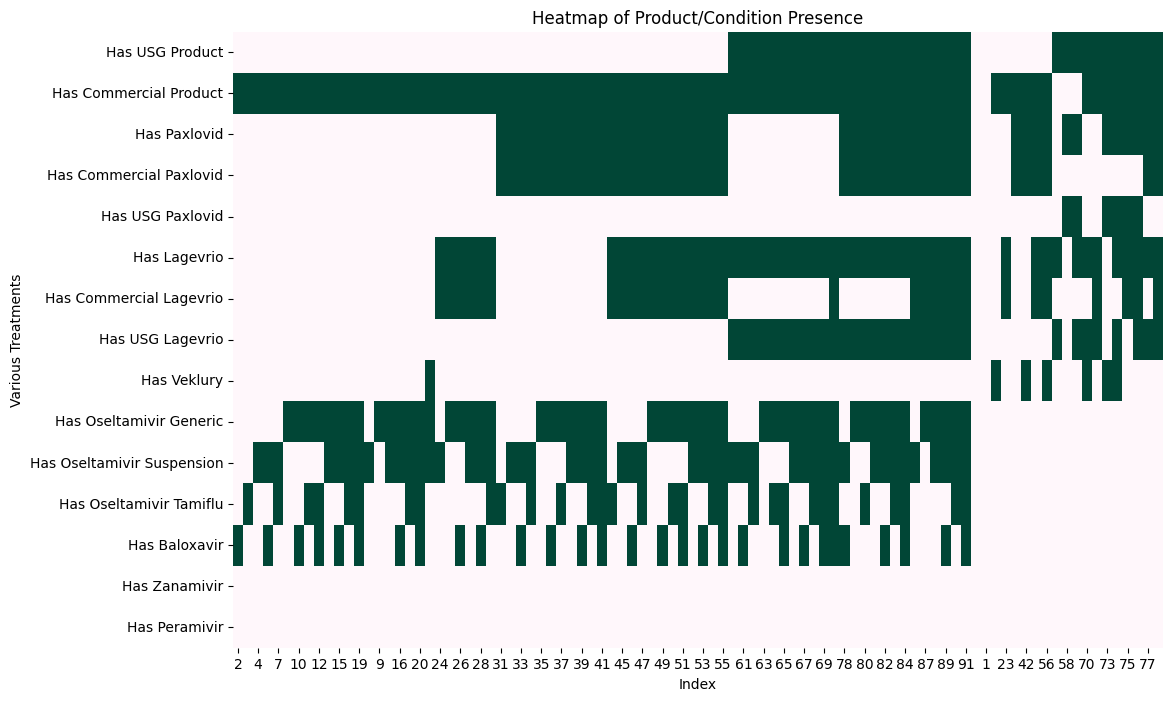

In [20]:
# Place all boolean columns in one spot
boolean_cols = sorted_data.columns[:-3]

# Converts True to value of 1 and Fals to value of 0
sorted_data_boolean = sorted_data[boolean_cols].astype(int)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data_boolean.T, cmap="PuBuGn", cbar=False, annot=False)
plt.title('Heatmap of Product/Condition Presence')
plt.xlabel('Index')
plt.ylabel('Various Treatments')
plt.show()

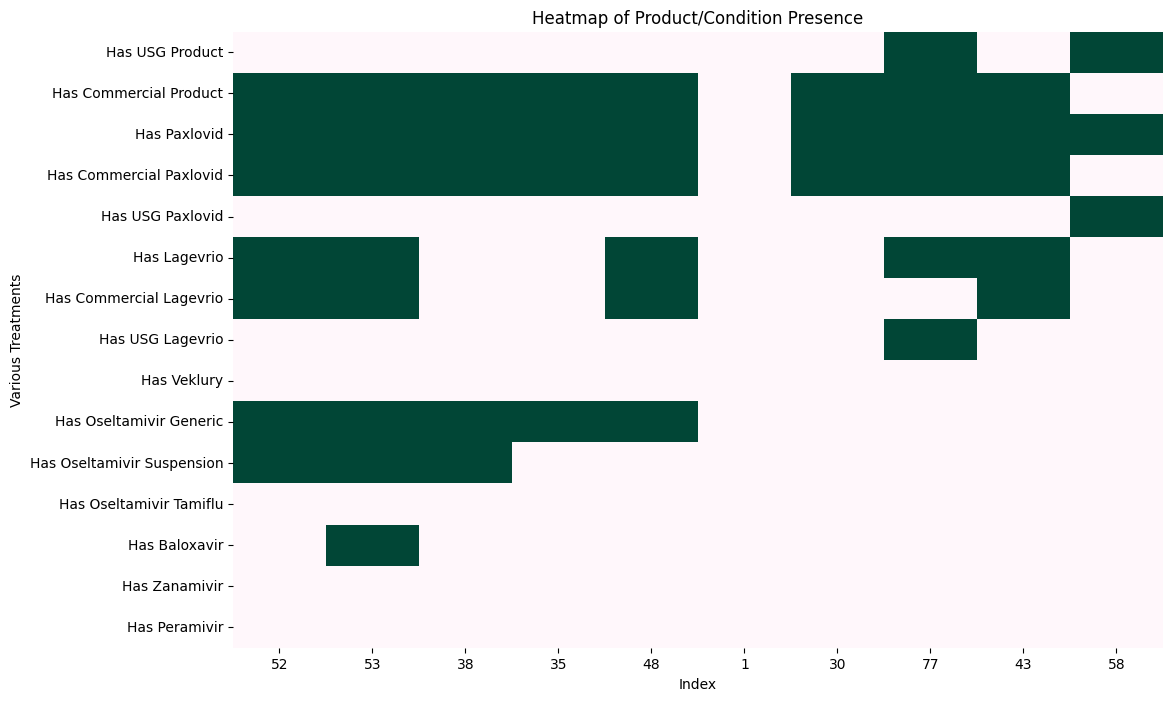

In [21]:
# Place all boolean columns in one spot
boolean_cols_2 = sorted_data_2.columns[:-3]

# Converts True to value of 1 and Fals to value of 0
sorted_data_boolean_2  = sorted_data_2[boolean_cols].astype(int)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data_boolean_2.T, cmap="PuBuGn", cbar=False, annot=False)
plt.title('Heatmap of Product/Condition Presence')
plt.xlabel('Index')
plt.ylabel('Various Treatments')
plt.show()

TypeError: 'bool' object is not iterable

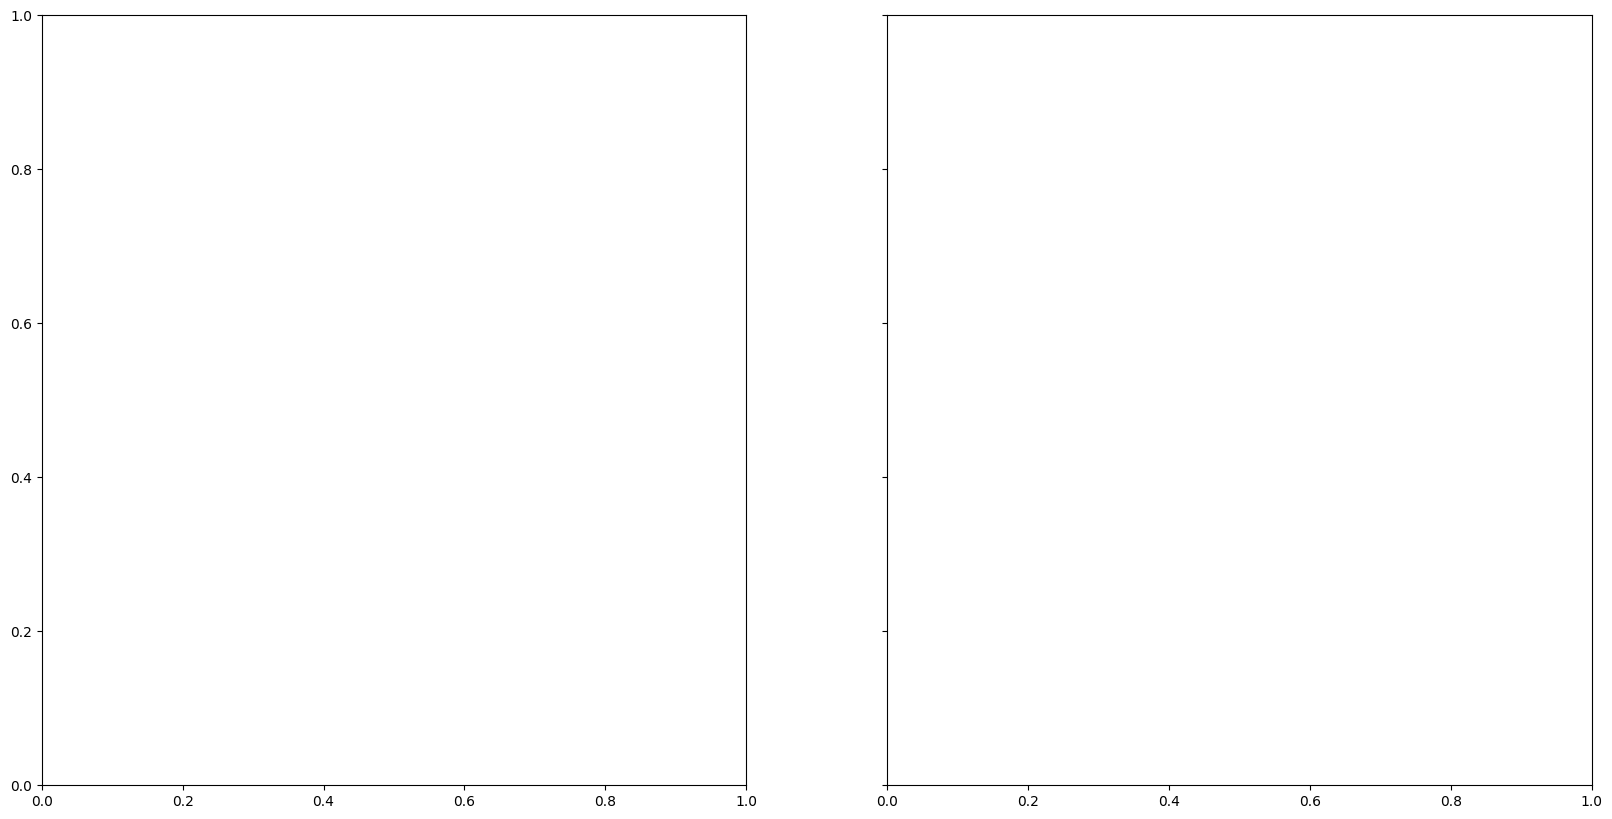

In [25]:
boolean_cols = sorted_data.columns[:-3]  # Exclude 'count' "is flu" and "is covid-19" columns
group_columns = ['Is Flu', 'Is COVID-19'] == True
# Select a colormap (e.g., 'Set2', 'Paired', 'tab20', etc.)


# Initialize the plot
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# Loop through the Is Flu and Is COVID-19 columns
for i, col in enumerate(group_columns):
        if group_columns == True:
    # Count the occurrences of True (sum) for each boolean column by group (Is Flu or Is COVID-19)
            group_counts = sorted_data.groupby(col)[boolean_cols].sum()

                # Plot a stacked bar plot
            group_counts.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
            axes[i].set_title(f'Comparison with {col}')
            axes[i].set_xlabel('ASPR Treatment')
            axes[i].set_ylabel('Total count of True')
            axes[i].tick_params(axis='x', rotation=90)


# Adjust layout
plt.tight_layout()
plt.show()



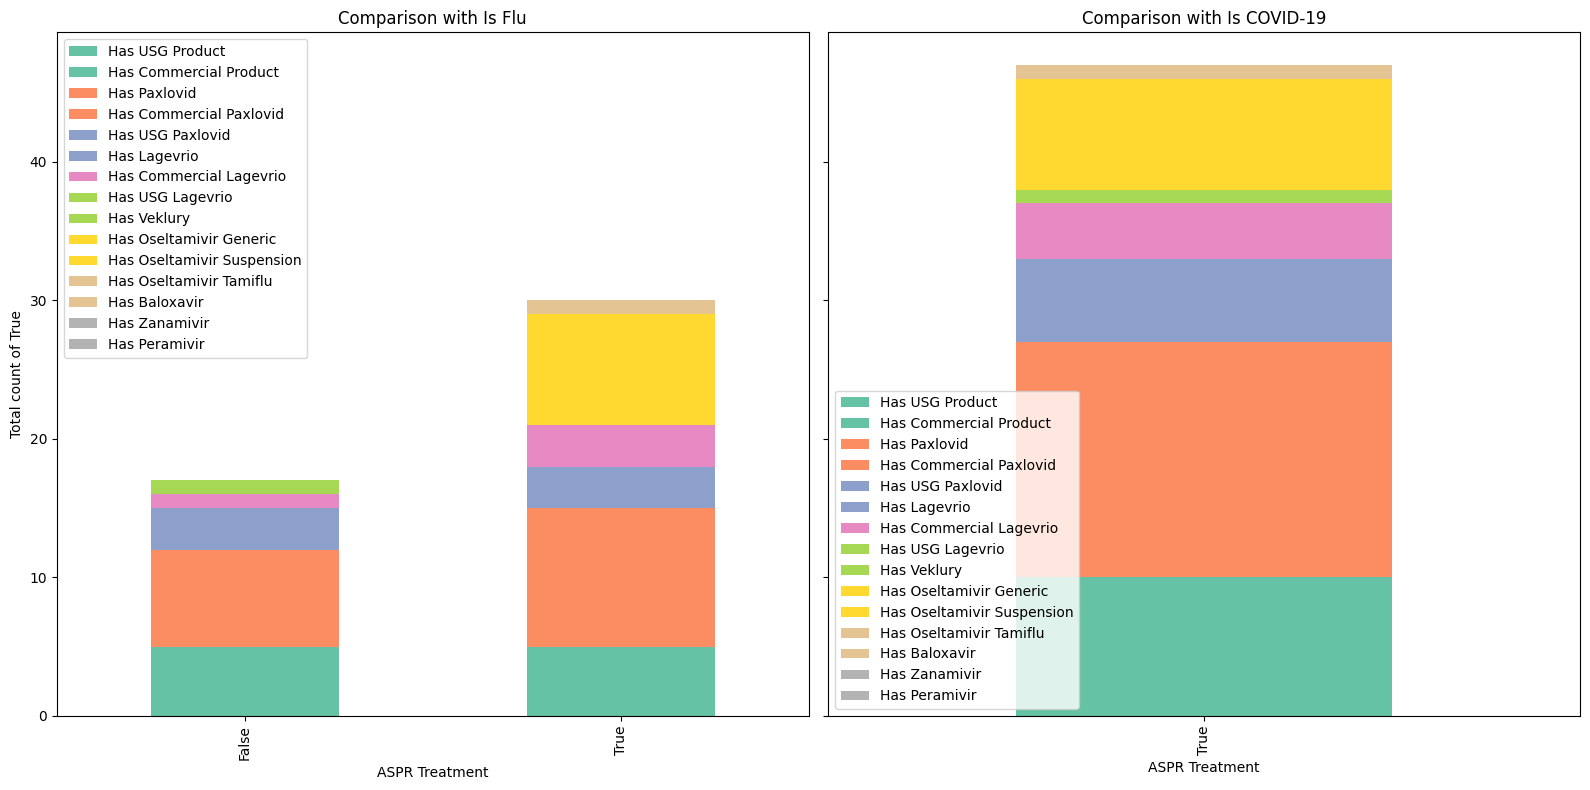

In [ ]:
# Looking at top 10 counts
boolean_cols_2 = sorted_data_2.columns[:-3]  # Exclude 'count' "is flu" and "is covid-19" columns
group_columns = ['Is Flu', 'Is COVID-19']
# Select a colormap (e.g., 'Set2', 'Paired', 'tab20', etc.)


# Initialize the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)


# Loop through the Is Flu and Is COVID-19 columns
for i, col in enumerate(group_columns):
    # Count the occurrences of True (sum) for each boolean column by group (Is Flu or Is COVID-19)
    group_counts_2 = sorted_data_2.groupby(col)[boolean_cols_2].sum()



    # Plot a stacked bar plot
    group_counts_2.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
    axes[i].set_title(f'Comparison with {col}')
    axes[i].set_xlabel('ASPR Treatment')
    axes[i].set_ylabel('Total count of True')
    axes[i].tick_params(axis='x', rotation=90)


# Adjust layout
plt.tight_layout()
plt.show()

